START CALCULATION

--- Penalty Method ---
Penalty: iter 1, r=4.00, x=[0.83228291 0.69035745]
Penalty: iter 2, r=16.00, x=[0.80218659 0.64073317]
Penalty: iter 3, r=64.00, x=[0.79132864 0.62327465]
Penalty: iter 4, r=256.00, x=[0.7882603 0.6183838]
Penalty: iter 5, r=1024.00, x=[0.78746684 0.61712212]
Penalty: iter 6, r=4096.00, x=[0.78726674 0.61680415]
Penalty: iter 7, r=16384.00, x=[0.78721659 0.61672451]
Penalty: iter 8, r=65536.00, x=[0.78720399 0.61670466]

RESULT Penalty Method:
  x* = [0.787201, 0.616700]
  f(x*) = 10.091013
  Constraint violation: max(g) = 3.68e-06

--- Barrier Method ---
Barrier: iter 1, r=0.100000, x=[0.64909252 0.42369389]
Barrier: iter 2, r=0.010000, x=[0.72647522 0.52435754]
Barrier: iter 3, r=0.001000, x=[0.77666584 0.60010314]
Barrier: iter 4, r=0.000100, x=[0.78604328 0.61486448]
Barrier: iter 5, r=0.000010, x=[0.78708303 0.61651256]
Barrier: iter 6, r=0.000001, x=[0.78718816 0.6166794 ]
Barrier: iter 7, r=0.000000, x=[0.78718816 0.6166794 ]
Barrier: it

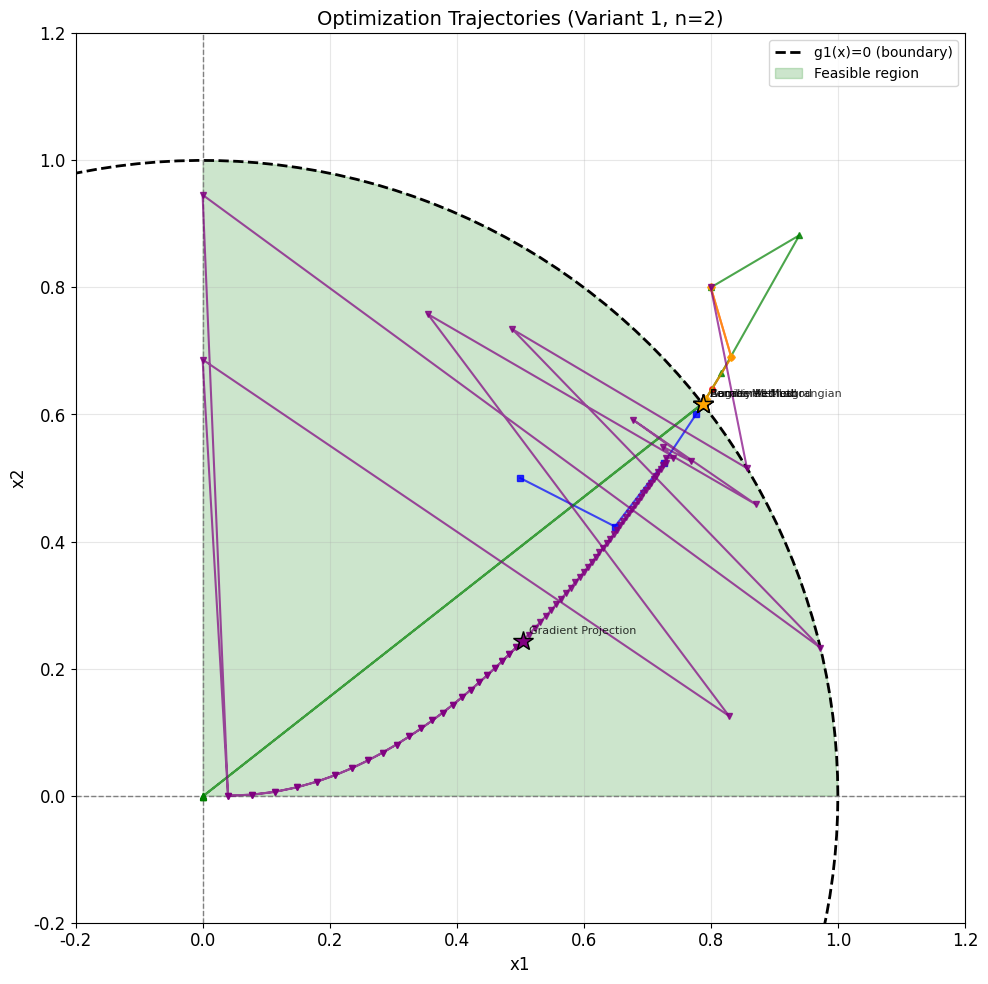


CALCULATION COMPLETE

SUMMARY TABLE
--------------------------------------------------------------------------------
Method                         x1           x2           f(x)         max(g)      
--------------------------------------------------------------------------------
Penalty Method                 0.787201     0.616700     10.091013    3.68e-06    
Barrier Method                 0.787188     0.616679     10.091024    -4.13e-05   
Combined Method                0.787182     0.616720     10.091014    5.18e-08    
Augmented Lagrangian           0.787200     0.616698     10.091014    -1.06e-08   
Gradient Projection            0.503655     0.243592     10.497793    -2.44e-01   
--------------------------------------------------------------------------------


In [ ]:
# -*- coding: utf-8 -*-
"""
Методы условной оптимизации / 约束优化方法
Основной вариант лабораторной работы №4 / 第4次实验主要方案
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Настройка matplotlib для работы без китайских символов / 设置matplotlib避免中文字符
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Используем шрифт без кириллицы? / 使用不含中文的字体
plt.rcParams['axes.unicode_minus'] = False

# ------------------------- Параметры (вариант 1) / 参数设置（变体1）-------------------------
a = 50.0
b = 2.0
f0 = 10.0
n = 2

# Целевая функция Розенброка / Rosenbrock目标函数
def rosenbrock(x):
    x = np.array(x)
    s = 0.0
    for i in range(n-1):
        s += a * (x[i]**2 - x[i+1])**2 + b * (x[i] - 1)**2
    return s + f0

# Функции ограничений / 约束函数
def g1(x): return x[0]**2 + x[1]**2 - 1.0   # ≤ 0
def g2(x): return -x[0]                      # ≤ 0
def g3(x): return -x[1]                      # ≤ 0

# Все ограничения в виде вектора / 所有约束组成向量
def constraints_vec(x):
    return np.array([g1(x), g2(x), g3(x)])

# Проверка допустимости решения / 检查解是否可行
def is_feasible(x, eps=1e-6):
    return constraints_vec(x).max() <= eps

# ------------------------- Метод 1: Штрафные функции (внешние) / 方法1：罚函数法（外部）-------------------------
def penalty_method(x0, r0=1.0, C=4, eps=1e-6, max_iter=20):
    """Метод штрафных функций / 罚函数法"""
    x = np.array(x0)
    r = r0
    history = [x.copy()]
    for k in range(max_iter):
        def penalty_func(x_vec):
            xv = np.array(x_vec)
            fv = rosenbrock(xv)
            penalty = 0.0
            gv = constraints_vec(xv)
            for gi in gv:
                penalty += max(0, gi)**2
            return fv + (r/2) * penalty
        res = minimize(penalty_func, x, method='BFGS')
        x_new = res.x
        history.append(x_new.copy())
        p = 0.0
        gv = constraints_vec(x_new)
        for gi in gv:
            p += max(0, gi)**2
        p *= (r/2)
        if p <= eps:
            break
        r *= C
        x = x_new
        print(f"Penalty: iter {k+1}, r={r:.2f}, x={x_new}")
    return x_new, history

# ------------------------- Метод 2: Барьерные функции (внутренние) / 方法2：障碍函数法（内部）-------------------------
def barrier_method(x0, r0=1.0, C=10, eps=1e-6, max_iter=20):
    """Метод барьерных функций / 障碍函数法"""
    x = np.array(x0)
    if not (g1(x) < 0 and g2(x) < 0 and g3(x) < 0):
        print("Warning: initial point infeasible, adjusting...")
        x = np.array([0.5, 0.5])
    r = r0
    history = [x.copy()]
    for k in range(max_iter):
        def barrier_func(x_vec):
            xv = np.array(x_vec)
            fv = rosenbrock(xv)
            barrier = 0.0
            gv = constraints_vec(xv)
            for gi in gv:
                if -gi < 1e-12:
                    return 1e10
                barrier += np.log(-gi)
            return fv - r * barrier
        res = minimize(barrier_func, x, method='BFGS')
        x_new = res.x
        history.append(x_new.copy())
        barrier_val = 0.0
        gv = constraints_vec(x_new)
        for gi in gv:
            barrier_val += np.log(-gi) if gi < 0 else 1e10
        if np.abs(r * barrier_val) <= eps:
            break
        r /= C
        x = x_new
        print(f"Barrier: iter {k+1}, r={r:.6f}, x={x_new}")
    return x_new, history

# ------------------------- Метод 3: Комбинированный (штраф + барьер) / 方法3：组合法（罚+障碍）-------------------------
def combined_method(x0, r0=1.0, C=4, eps=1e-6, max_iter=20):
    """Комбинированный метод / 组合法"""
    x = np.array(x0)
    r = r0
    history = [x.copy()]
    for k in range(max_iter):
        def combined_func(x_vec):
            xv = np.array(x_vec)
            fv = rosenbrock(xv)
            ext = 0.0
            int_pen = 0.0
            gv = constraints_vec(xv)
            for gi in gv:
                ext += max(0, gi)**2
                if gi < 0:
                    int_pen += np.log(-gi)
                else:
                    int_pen += 1e6
            return fv + (r/2)*ext - (1.0/r)*int_pen
        res = minimize(combined_func, x, method='BFGS')
        x_new = res.x
        history.append(x_new.copy())
        if is_feasible(x_new, eps):
            break
        r *= C
        x = x_new
        print(f"Combined: iter {k+1}, r={r:.2f}, x={x_new}")
    return x_new, history

# ------------------------- Метод 4: Модифицированная функция Лагранжа / 方法4：修正拉格朗日函数法-------------------------
def augmented_lagrangian_method(x0, mu0=1.0, C=4, eps=1e-6, max_iter=20):
    """Метод модифицированных функций Лагранжа / 修正拉格朗日函数法"""
    x = np.array(x0)
    lam = np.zeros(3)
    r = mu0
    history = [x.copy()]
    for k in range(max_iter):
        def aug_lag_func(x_vec):
            xv = np.array(x_vec)
            fv = rosenbrock(xv)
            gv = constraints_vec(xv)
            total = fv
            for j in range(3):
                gj = gv[j]
                if lam[j] + r * gj > 0:
                    total += (1/(2*r)) * (max(0, lam[j] + r * gj)**2 - lam[j]**2)
                else:
                    total += -lam[j]**2/(2*r)
            return total
        res = minimize(aug_lag_func, x, method='BFGS')
        x_new = res.x
        history.append(x_new.copy())
        g_new = constraints_vec(x_new)
        for j in range(3):
            lam[j] = max(0, lam[j] + r * g_new[j])
        if np.max(g_new) <= eps:
            break
        r *= C
        x = x_new
        print(f"Augmented Lagrangian: iter {k+1}, r={r:.2f}, lam={lam}, x={x_new}")
    return x_new, history

# ------------------------- Метод 5: Проекция градиента / 方法5：梯度投影法-------------------------
def gradient_projection(x0, alpha0=0.01, max_iter=100, eps=1e-6):
    """Метод проекции градиента / 梯度投影法"""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for it in range(max_iter):
        grad = np.zeros(2)
        fx = rosenbrock(x)
        h = 1e-6
        for i in range(2):
            xp = x.copy()
            xp[i] += h
            grad[i] = (rosenbrock(xp) - fx) / h
        x_new = x - alpha0 * grad
        x_new[0] = max(0, x_new[0])
        x_new[1] = max(0, x_new[1])
        if x_new[0]**2 + x_new[1]**2 > 1:
            norm = np.sqrt(x_new[0]**2 + x_new[1]**2)
            x_new = x_new / norm
        if np.linalg.norm(x_new - x) < eps:
            history.append(x_new.copy())
            break
        x = x_new
        history.append(x.copy())
        if it % 20 == 0:
            print(f"Gradient Projection: iter {it}, x={x}, f={rosenbrock(x):.6f}")
    return x, history

# ------------------------- Тестирование и визуализация / 测试与绘图-------------------------
print("=" * 60)
print("START CALCULATION")
print("=" * 60)

x0 = [0.8, 0.8]

methods = [
    ("Penalty Method", penalty_method),
    ("Barrier Method", barrier_method),
    ("Combined Method", combined_method),
    ("Augmented Lagrangian", augmented_lagrangian_method),
    ("Gradient Projection", gradient_projection)
]

results = {}

for name, method in methods:
    print(f"\n--- {name} ---")
    if name == "Gradient Projection":
        x_opt, hist = gradient_projection(x0)
    else:
        x_opt, hist = method(x0)
    results[name] = {
        'x': x_opt,
        'f': rosenbrock(x_opt),
        'history': hist
    }
    print(f"\nRESULT {name}:")
    print(f"  x* = [{x_opt[0]:.6f}, {x_opt[1]:.6f}]")
    print(f"  f(x*) = {rosenbrock(x_opt):.6f}")
    print(f"  Constraint violation: max(g) = {constraints_vec(x_opt).max():.2e}")

print("\n" + "=" * 60)
print("VISUALIZATION")
print("=" * 60)

# Создаем фигуру с правильными настройками / 创建正确配置的图形
fig, ax = plt.subplots(figsize=(10, 10))

# Рисуем границу g1=0 (окружность) / 绘制约束边界 g1=0（圆）
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=2, label='g1(x)=0 (boundary)')

# Рисуем оси x1=0, x2=0 / 绘制坐标轴边界
ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.axvline(0, color='gray', linewidth=1, linestyle='--')

# Закрашиваем допустимую область / 填充可行域
x_fill = np.linspace(0, 1, 100)
y_fill = np.sqrt(1 - x_fill**2)
ax.fill_between(x_fill, 0, y_fill, alpha=0.2, color='green', label='Feasible region')

# Рисуем траектории / 绘制各方法的优化路径
colors = ['red', 'blue', 'green', 'orange', 'purple']
markers = ['o', 's', '^', 'D', 'v']

for (name, res), color, marker in zip(results.items(), colors, markers):
    hist = np.array(res['history'])
    # Рисуем траекторию / 绘制路径线
    ax.plot(hist[:,0], hist[:,1], '-', color=color, linewidth=1.5, alpha=0.7)
    # Рисуем точки / 绘制迭代点
    ax.plot(hist[:,0], hist[:,1], marker, color=color, markersize=4, alpha=0.8)
    # Отмечаем конечную точку / 标记终点
    ax.plot(res['x'][0], res['x'][1], '*', color=color, markersize=15, markeredgecolor='black', markeredgewidth=1)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Optimization Trajectories (Variant 1, n=2)', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_aspect('equal')

# Добавляем подписи конечных точек / 添加终点标签
for name, res in results.items():
    ax.annotate(name,
                xy=(res['x'][0], res['x'][1]),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                alpha=0.8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CALCULATION COMPLETE")
print("=" * 60)

# Сводная таблица / 汇总表
print("\nSUMMARY TABLE")
print("-" * 80)
print(f"{'Method':<30} {'x1':<12} {'x2':<12} {'f(x)':<12} {'max(g)':<12}")
print("-" * 80)
for name, res in results.items():
    maxg = constraints_vec(res['x']).max()
    print(f"{name:<30} {res['x'][0]:<12.6f} {res['x'][1]:<12.6f} {res['f']:<12.6f} {maxg:<12.2e}")
print("-" * 80)

SECONDARY VARIANT 2 / ВСПОМОГАТЕЛЬНЫЙ ВАРИАНТ 2
Necessary and sufficient conditions for conditional extremum
Необходимые и достаточные условия условного экстремума

PART 1: SYMBOLIC SOLUTION / ЧАСТЬ 1: СИМВОЛЬНОЕ РЕШЕНИЕ

Целевая функция f(x) = x1*x2 + (x1 - 2)**2 + (x2 - 3)**2
Ограничение g1(x) = x1**2 + x2**2 - 52 <= 0
Ограничение g2(x) = -x1 <= 0
Ограничение g3(x) = -x2 <= 0

--------------------------------------------------
1.1 Lagrange function / Функция Лагранжа
--------------------------------------------------
L(x, λ) = lambda1*(x1**2 + x2**2 - 52) - lambda2*x1 - lambda3*x2 + x1*x2 + (x1 - 2)**2 + (x2 - 3)**2

--------------------------------------------------
1.2 First-order necessary conditions (KKT conditions)
Необходимые условия первого порядка (условия ККТ)
--------------------------------------------------

∂L/∂x1 = 2*lambda1*x1 - lambda2 + 2*x1 + x2 - 4 = 0
∂L/∂x2 = 2*lambda1*x2 - lambda3 + x1 + 2*x2 - 6 = 0

Допустимость / Feasibility:
  g1 = x1**2 + x2**2 - 52 ≤ 0
  g

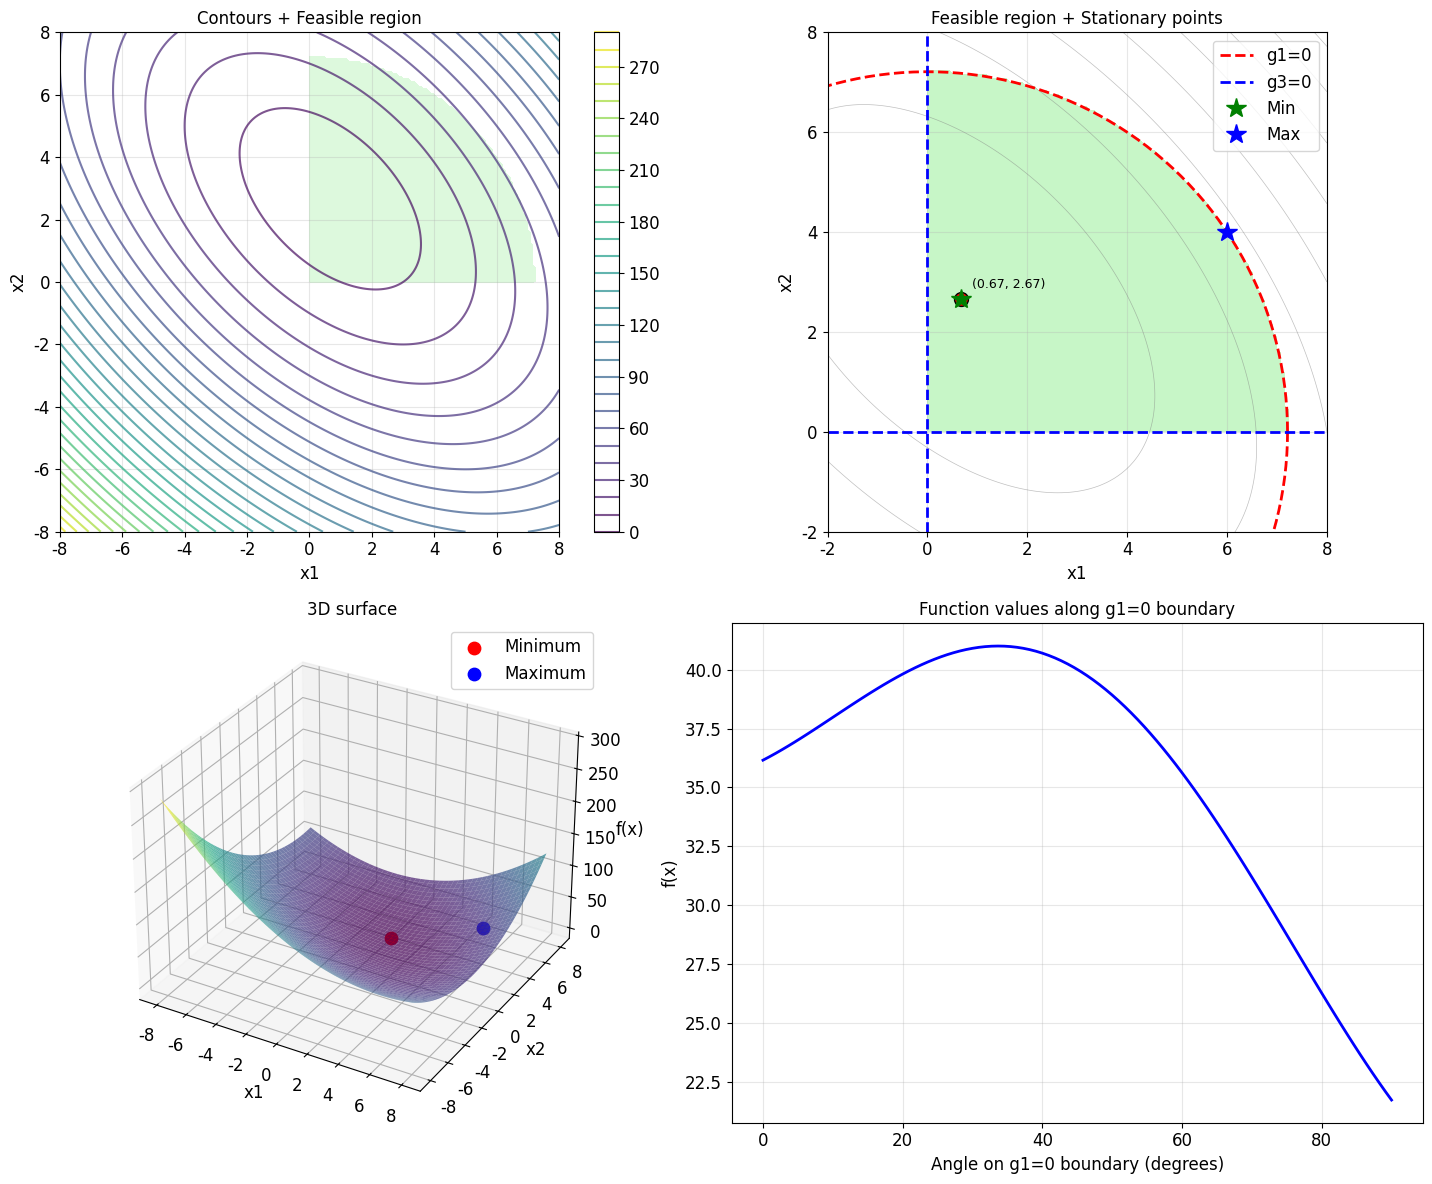


SUMMARY TABLE / СВОДНАЯ ТАБЛИЦА
Point    x1           x2           f(x)         Active constraints  
------------------------------------------------------------
1        0.666667     2.666667     3.666667     none                

Numerical optimization results:
  Minimum: x=[0.666667, 2.666667], f=3.666667
  Maximum: x=[6.000000, 4.000001], f=41.000000
CALCULATION COMPLETE / РАСЧЁТ ЗАВЕРШЁН


In [ ]:
# -*- coding: utf-8 -*-
"""
Вспомогательный вариант №2 / 辅助方案2
Исследование необходимых и достаточных условий условного экстремума
条件极值的必要与充分条件研究

Задача 1.1 / 任务1.1:
f(x) = (x1-2)^2 + (x2-3)^2 + x1*x2 -> extr
g1(x) = x1^2 + x2^2 - 52 <= 0
g2(x) = -x1 <= 0
g3(x) = -x2 <= 0
"""

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Настройка matplotlib / 设置matplotlib
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 70)
print("SECONDARY VARIANT 2 / ВСПОМОГАТЕЛЬНЫЙ ВАРИАНТ 2")
print("Necessary and sufficient conditions for conditional extremum")
print("Необходимые и достаточные условия условного экстремума")
print("=" * 70)

# ----------------------------------------------------------------------
# ЧАСТЬ 1: СИМВОЛЬНОЕ РЕШЕНИЕ С ПОМОЩЬЮ SYMPY / 第一部分：符号求解
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("PART 1: SYMBOLIC SOLUTION / ЧАСТЬ 1: СИМВОЛЬНОЕ РЕШЕНИЕ")
print("=" * 70)

# Определяем символьные переменные / 定义符号变量
x1, x2 = sp.symbols('x1 x2', real=True)
lam1, lam2, lam3 = sp.symbols('lambda1 lambda2 lambda3', real=True)

# Целевая функция / 目标函数
f = (x1 - 2)**2 + (x2 - 3)**2 + x1 * x2

# Функции ограничений / 约束函数
g1 = x1**2 + x2**2 - 52  # <= 0
g2 = -x1                  # <= 0
g3 = -x2                  # <= 0

print(f"\nЦелевая функция f(x) = {f}")
print(f"Ограничение g1(x) = {g1} <= 0")
print(f"Ограничение g2(x) = {g2} <= 0")
print(f"Ограничение g3(x) = {g3} <= 0")

# ----------------------------------------------------------------------
# 1.1 Функция Лагранжа / 拉格朗日函数
# ----------------------------------------------------------------------
print("\n" + "-" * 50)
print("1.1 Lagrange function / Функция Лагранжа")
print("-" * 50)

# Классическая функция Лагранжа (λ0 = 1) / 经典拉格朗日函数
L = f + lam1 * g1 + lam2 * g2 + lam3 * g3
print(f"L(x, λ) = {L}")

# ----------------------------------------------------------------------
# 1.2 Необходимые условия первого порядка / 一阶必要条件
# ----------------------------------------------------------------------
print("\n" + "-" * 50)
print("1.2 First-order necessary conditions (KKT conditions)")
print("Необходимые условия первого порядка (условия ККТ)")
print("-" * 50)

# Стационарность по x / 对x的平稳性条件
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)

print(f"\n∂L/∂x1 = {dL_dx1} = 0")
print(f"∂L/∂x2 = {dL_dx2} = 0")

# Условия допустимости / 可行性条件
print(f"\nДопустимость / Feasibility:")
print(f"  g1 = {g1} ≤ 0")
print(f"  g2 = {g2} ≤ 0")
print(f"  g3 = {g3} ≤ 0")

# Условия неотрицательности (для минимума) / 非负性条件（最小值）
print(f"\nУсловия неотрицательности (для минимума) / Non-negativity (for minimum):")
print(f"  λ1 ≥ 0, λ2 ≥ 0, λ3 ≥ 0")

# Условия дополняющей нежесткости / 互补松弛条件
print(f"\nУсловия дополняющей нежесткости / Complementary slackness:")
print(f"  λ1 * g1 = 0")
print(f"  λ2 * g2 = 0")
print(f"  λ3 * g3 = 0")

# ----------------------------------------------------------------------
# Вспомогательная функция для проверки решения / 辅助函数：检查解是否有效
# ----------------------------------------------------------------------
def is_valid_solution(x1_val, x2_val, lam_vals, tol=1e-10):
    """Проверка, что решение действительное и удовлетворяет ограничениям"""
    # Проверка на комплексные числа / 检查是否为复数
    if hasattr(x1_val, 'is_real') and x1_val.is_real == False:
        return False
    if hasattr(x2_val, 'is_real') and x2_val.is_real == False:
        return False
    try:
        x1_float = float(x1_val)
        x2_float = float(x2_val)
    except (TypeError, ValueError):
        return False

    # Проверка на NaN и Inf / 检查NaN和Inf
    if np.isnan(x1_float) or np.isnan(x2_float):
        return False
    if np.isinf(x1_float) or np.isinf(x2_float):
        return False

    # Проверка мнимой части / 检查虚部
    if np.imag(x1_float) != 0 or np.imag(x2_float) != 0:
        return False

    x1_float = float(np.real(x1_float))
    x2_float = float(np.real(x2_float))

    # Проверка ограничений / 检查约束
    g1_val = float(g1.subs({x1: x1_float, x2: x2_float}))
    if g1_val > tol:
        return False

    # Проверка множителей Лагранжа / 检查拉格朗日乘子
    for lam_val in lam_vals:
        if lam_val is not None:
            try:
                lam_float = float(lam_val)
                if lam_float < -tol:
                    return False
            except (TypeError, ValueError):
                pass

    return True

# ----------------------------------------------------------------------
# 1.3 Решение системы / 求解系统
# ----------------------------------------------------------------------
print("\n" + "-" * 50)
print("1.3 Solving the KKT system / Решение системы ККТ")
print("-" * 50)

cases = []

# Случай 1: Нет активных ограничений (все λ = 0) / 情况1：无活动约束
print("\n--- Case 1: No active constraints (λ1=λ2=λ3=0) ---")
eq1 = dL_dx1.subs({lam1: 0, lam2: 0, lam3: 0})
eq2 = dL_dx2.subs({lam1: 0, lam2: 0, lam3: 0})
print(f"  Equations: {eq1}=0, {eq2}=0")
solution = sp.solve([eq1, eq2], [x1, x2], dict=True)
for sol in solution:
    try:
        x1_val = float(sol[x1])
        x2_val = float(sol[x2])
        g1_val = float(g1.subs({x1: x1_val, x2: x2_val}))
        g2_val = float(g2.subs({x1: x1_val, x2: x2_val}))
        g3_val = float(g3.subs({x1: x1_val, x2: x2_val}))
        if g1_val <= 1e-6 and g2_val <= 1e-6 and g3_val <= 1e-6:
            print(f"  Found: x1={x1_val:.6f}, x2={x2_val:.6f}")
            cases.append({'x': (x1_val, x2_val), 'lam': (0,0,0), 'active': []})
    except Exception as e:
        print(f"  Skipping invalid solution: {e}")

# Случай 2: g1 активно (λ1>0, λ2=0, λ3=0, g1=0) / 情况2：g1活动
print("\n--- Case 2: g1 active (g1=0, λ1>0, λ2=0, λ3=0) ---")
eq1 = dL_dx1.subs({lam2: 0, lam3: 0})
eq2 = dL_dx2.subs({lam2: 0, lam3: 0})
eq_g1 = g1
print(f"  Solving: ∂L/∂x1=0, ∂L/∂x2=0, g1=0")
try:
    solution = sp.solve([eq1, eq2, eq_g1], [x1, x2, lam1], dict=True)
    for sol in solution:
        try:
            x1_val = float(sol[x1])
            x2_val = float(sol[x2])
            lam1_val = float(sol[lam1])
            # Проверка, что решение действительное / 检查是否为实数解
            if np.isreal(x1_val) and np.isreal(x2_val) and np.isreal(lam1_val):
                x1_val = np.real(x1_val)
                x2_val = np.real(x2_val)
                lam1_val = np.real(lam1_val)
                g2_val = float(g2.subs({x1: x1_val, x2: x2_val}))
                g3_val = float(g3.subs({x1: x1_val, x2: x2_val}))
                if lam1_val > 0 and g2_val <= 1e-6 and g3_val <= 1e-6:
                    print(f"  Found: x1={x1_val:.6f}, x2={x2_val:.6f}, λ1={lam1_val:.6f}")
                    cases.append({'x': (x1_val, x2_val), 'lam': (lam1_val,0,0), 'active': ['g1']})
        except Exception as e:
            print(f"  Skipping: {e}")
except Exception as e:
    print(f"  No real solution or error: {e}")

# Случай 3: g2 активно (λ2>0, λ1=0, λ3=0, x1=0) / 情况3：g2活动
print("\n--- Case 3: g2 active (x1=0, λ2>0, λ1=0, λ3=0) ---")
eq1 = dL_dx1.subs({x1: 0, lam1: 0, lam3: 0})
eq2 = dL_dx2.subs({lam1: 0, lam3: 0})
eq_g2 = g2
print(f"  Solving: ∂L/∂x1=0, ∂L/∂x2=0, x1=0")
try:
    solution = sp.solve([eq1, eq2, eq_g2], [x1, x2, lam2], dict=True)
    for sol in solution:
        try:
            x1_val = float(sol[x1])
            x2_val = float(sol[x2])
            lam2_val = float(sol[lam2])
            if np.isreal(x1_val) and np.isreal(x2_val) and np.isreal(lam2_val):
                x1_val = np.real(x1_val)
                x2_val = np.real(x2_val)
                lam2_val = np.real(lam2_val)
                g1_val = float(g1.subs({x1: x1_val, x2: x2_val}))
                g3_val = float(g3.subs({x1: x1_val, x2: x2_val}))
                if lam2_val > 0 and g1_val <= 1e-6 and g3_val <= 1e-6:
                    print(f"  Found: x1={x1_val:.6f}, x2={x2_val:.6f}, λ2={lam2_val:.6f}")
                    cases.append({'x': (x1_val, x2_val), 'lam': (0,lam2_val,0), 'active': ['g2']})
        except Exception as e:
            print(f"  Skipping: {e}")
except Exception as e:
    print(f"  No real solution or error: {e}")

# Случай 4: g3 активно (λ3>0, λ1=0, λ2=0, x2=0) / 情况4：g3活动
print("\n--- Case 4: g3 active (x2=0, λ3>0, λ1=0, λ2=0) ---")
eq1 = dL_dx1.subs({lam1: 0, lam2: 0})
eq2 = dL_dx2.subs({x2: 0, lam1: 0, lam2: 0})
eq_g3 = g3
print(f"  Solving: ∂L/∂x1=0, ∂L/∂x2=0, x2=0")
try:
    solution = sp.solve([eq1, eq2, eq_g3], [x1, x2, lam3], dict=True)
    for sol in solution:
        try:
            x1_val = float(sol[x1])
            x2_val = float(sol[x2])
            lam3_val = float(sol[lam3])
            if np.isreal(x1_val) and np.isreal(x2_val) and np.isreal(lam3_val):
                x1_val = np.real(x1_val)
                x2_val = np.real(x2_val)
                lam3_val = np.real(lam3_val)
                g1_val = float(g1.subs({x1: x1_val, x2: x2_val}))
                g2_val = float(g2.subs({x1: x1_val, x2: x2_val}))
                if lam3_val > 0 and g1_val <= 1e-6 and g2_val <= 1e-6:
                    print(f"  Found: x1={x1_val:.6f}, x2={x2_val:.6f}, λ3={lam3_val:.6f}")
                    cases.append({'x': (x1_val, x2_val), 'lam': (0,0,lam3_val), 'active': ['g3']})
        except Exception as e:
            print(f"  Skipping: {e}")
except Exception as e:
    print(f"  No real solution or error: {e}")

# Случай 5: g1 и g2 активны (x1=0, g1=0) / 情况5：g1和g2同时活动
print("\n--- Case 5: g1 and g2 active (g1=0, x1=0) ---")
eq1 = dL_dx1.subs({x1: 0, lam3: 0})
eq2 = dL_dx2.subs({lam3: 0})
eq_g1 = g1.subs({x1: 0})
eq_g2 = g2
print(f"  Solving: ∂L/∂x1=0, ∂L/∂x2=0, g1=0, x1=0")
try:
    solution = sp.solve([eq1, eq2, eq_g1, eq_g2], [x1, x2, lam1, lam2], dict=True)
    for sol in solution:
        try:
            x1_val = float(sol[x1])
            x2_val = float(sol[x2])
            lam1_val = float(sol[lam1])
            lam2_val = float(sol[lam2])
            if np.isreal(x1_val) and np.isreal(x2_val):
                x1_val = np.real(x1_val)
                x2_val = np.real(x2_val)
                lam1_val = np.real(lam1_val)
                lam2_val = np.real(lam2_val)
                g3_val = float(g3.subs({x1: x1_val, x2: x2_val}))
                if lam1_val > 0 and lam2_val > 0 and g3_val <= 1e-6:
                    print(f"  Found: x1={x1_val:.6f}, x2={x2_val:.6f}, λ1={lam1_val:.6f}, λ2={lam2_val:.6f}")
                    cases.append({'x': (x1_val, x2_val), 'lam': (lam1_val,lam2_val,0), 'active': ['g1','g2']})
        except Exception as e:
            print(f"  Skipping: {e}")
except Exception as e:
    print(f"  No real solution or error: {e}")

# Случай 6: g1 и g3 активны (x2=0, g1=0) / 情况6：g1和g3同时活动
print("\n--- Case 6: g1 and g3 active (g1=0, x2=0) ---")
eq1 = dL_dx1.subs({lam2: 0})
eq2 = dL_dx2.subs({x2: 0, lam2: 0})
eq_g1 = g1.subs({x2: 0})
eq_g3 = g3
print(f"  Solving: ∂L/∂x1=0, ∂L/∂x2=0, g1=0, x2=0")
try:
    solution = sp.solve([eq1, eq2, eq_g1, eq_g3], [x1, x2, lam1, lam3], dict=True)
    for sol in solution:
        try:
            x1_val = float(sol[x1])
            x2_val = float(sol[x2])
            lam1_val = float(sol[lam1])
            lam3_val = float(sol[lam3])
            if np.isreal(x1_val) and np.isreal(x2_val):
                x1_val = np.real(x1_val)
                x2_val = np.real(x2_val)
                lam1_val = np.real(lam1_val)
                lam3_val = np.real(lam3_val)
                g2_val = float(g2.subs({x1: x1_val, x2: x2_val}))
                if lam1_val > 0 and lam3_val > 0 and g2_val <= 1e-6:
                    print(f"  Found: x1={x1_val:.6f}, x2={x2_val:.6f}, λ1={lam1_val:.6f}, λ3={lam3_val:.6f}")
                    cases.append({'x': (x1_val, x2_val), 'lam': (lam1_val,0,lam3_val), 'active': ['g1','g3']})
        except Exception as e:
            print(f"  Skipping: {e}")
except Exception as e:
    print(f"  No real solution or error: {e}")

# Случай 7: Все три ограничения активны (x1=0, x2=0, g1=0) / 情况7：三个约束都活动
print("\n--- Case 7: All constraints active (x1=0, x2=0, g1=0) ---")
# Проверяем, может ли точка (0,0) удовлетворять g1=0 / 检查(0,0)是否满足g1=0
if abs(float(g1.subs({x1: 0, x2: 0}))) < 1e-6:
    print(f"  Found: x1=0, x2=0")
    cases.append({'x': (0, 0), 'lam': (0,0,0), 'active': ['g1','g2','g3']})

# ----------------------------------------------------------------------
# 1.4 Достаточные условия второго порядка / 二阶充分条件
# ----------------------------------------------------------------------
print("\n" + "-" * 50)
print("1.4 Second-order sufficient conditions")
print("Достаточные условия второго порядка")
print("-" * 50)

# Вычисляем вторые производные / 计算二阶导数
hessian = sp.Matrix([[sp.diff(L, x1, x1), sp.diff(L, x1, x2)],
                      [sp.diff(L, x2, x1), sp.diff(L, x2, x2)]])
print(f"\nГессиан функции Лагранжа / Hessian of Lagrange function:")
print(f"H = {hessian}")

# Вычисляем градиенты ограничений / 计算约束的梯度
grad_g1 = sp.Matrix([sp.diff(g1, x1), sp.diff(g1, x2)])
grad_g2 = sp.Matrix([sp.diff(g2, x1), sp.diff(g2, x2)])
grad_g3 = sp.Matrix([sp.diff(g3, x1), sp.diff(g3, x2)])

print(f"\nГрадиенты ограничений / Gradients of constraints:")
print(f"∇g1 = {grad_g1}")
print(f"∇g2 = {grad_g2}")
print(f"∇g3 = {grad_g3}")

# Анализ каждой стационарной точки / 分析每个驻点
print("\n" + "=" * 70)
print("STATIONARY POINTS ANALYSIS / АНАЛИЗ СТАЦИОНАРНЫХ ТОЧЕК")
print("=" * 70)

if not cases:
    print("\nNo stationary points found! / Стационарные точки не найдены!")
else:
    for i, case in enumerate(cases):
        print(f"\n--- Stationary point {i+1} ---")
        x1_val, x2_val = case['x']
        lam1_val, lam2_val, lam3_val = case['lam']
        active = case['active']

        print(f"Coordinates: x1 = {x1_val:.6f}, x2 = {x2_val:.6f}")
        print(f"Lagrange multipliers: λ1={lam1_val:.6f}, λ2={lam2_val:.6f}, λ3={lam3_val:.6f}")
        print(f"Active constraints: {active if active else 'none'}")

        # Вычисляем значение функции / 计算函数值
        f_val = float(f.subs({x1: x1_val, x2: x2_val}))
        print(f"f(x*) = {f_val:.6f}")

        # Проверка KKT условий / 检查KKT条件
        dL1 = float(dL_dx1.subs({x1: x1_val, x2: x2_val, lam1: lam1_val, lam2: lam2_val, lam3: lam3_val}))
        dL2 = float(dL_dx2.subs({x1: x1_val, x2: x2_val, lam1: lam1_val, lam2: lam2_val, lam3: lam3_val}))
        print(f"\nKKT conditions check:")
        print(f"  ∂L/∂x1 = {dL1:.2e}")
        print(f"  ∂L/∂x2 = {dL2:.2e}")

        # Достаточные условия / 充分条件
        H_num = hessian.subs({x1: x1_val, x2: x2_val, lam1: lam1_val, lam2: lam2_val, lam3: lam3_val})
        H_num = np.array(H_num).astype(float)

        print(f"\nHessian at this point:")
        print(f"  [{H_num[0,0]:.4f}, {H_num[0,1]:.4f}]")
        print(f"  [{H_num[1,0]:.4f}, {H_num[1,1]:.4f}]")

        eigenvals = np.linalg.eigvals(H_num)
        print(f"Eigenvalues: {eigenvals[0]:.4f}, {eigenvals[1]:.4f}")

        # Определяем тип экстремума / 判断极值类型
        if len(active) == 0:
            if eigenvals[0] > 0 and eigenvals[1] > 0:
                print(f"\n>>> CONCLUSION: Local MINIMUM (unconstrained) <<<")
            elif eigenvals[0] < 0 and eigenvals[1] < 0:
                print(f"\n>>> CONCLUSION: Local MAXIMUM (unconstrained) <<<")
            else:
                print(f"\n>>> CONCLUSION: Saddle point <<<")
        elif len(active) >= 2:
            print(f"\n>>> CONCLUSION: Boundary point with {len(active)} active constraints (corner) <<<")
        else:
            if 'g1' in active:
                grad = grad_g1
            elif 'g2' in active:
                grad = grad_g2
            elif 'g3' in active:
                grad = grad_g3
            else:
                grad = None

            if grad is not None:
                grad_num = np.array([float(grad[0].subs({x1: x1_val, x2: x2_val})),
                                      float(grad[1].subs({x1: x1_val, x2: x2_val}))])
                print(f"\nGradient of active constraint: {grad_num}")

                if abs(grad_num[0]) > 1e-6:
                    tangent = np.array([grad_num[1], -grad_num[0]])
                else:
                    tangent = np.array([1, 0])
                tangent = tangent / np.linalg.norm(tangent)
                print(f"Tangent direction: {tangent}")

                projected_hessian = tangent @ H_num @ tangent
                print(f"Projected Hessian along tangent: {projected_hessian:.6f}")

                if projected_hessian > 1e-6:
                    print(f"\n>>> CONCLUSION: Local MINIMUM (projected Hessian positive) <<<")
                elif projected_hessian < -1e-6:
                    print(f"\n>>> CONCLUSION: Local MAXIMUM (projected Hessian negative) <<<")
                else:
                    print(f"\n>>> CONCLUSION: Need higher-order analysis <<<")

# ----------------------------------------------------------------------
# ЧАСТЬ 2: ЧИСЛЕННАЯ ВЕРИФИКАЦИЯ / 第二部分：数值验证
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("PART 2: NUMERICAL VERIFICATION / ЧАСТЬ 2: ЧИСЛЕННАЯ ВЕРИФИКАЦИЯ")
print("=" * 70)

def objective(x):
    return (x[0]-2)**2 + (x[1]-3)**2 + x[0]*x[1]

def constraint1(x):
    return 52 - (x[0]**2 + x[1]**2)

def constraint2(x):
    return x[0]

def constraint3(x):
    return x[1]

cons = [
    {'type': 'ineq', 'fun': constraint1},
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3}
]

print("\nNumerical minimization:")
result_min = minimize(objective, [0, 0], method='SLSQP', constraints=cons)
print(f"  x* = [{result_min.x[0]:.6f}, {result_min.x[1]:.6f}]")
print(f"  f(x*) = {result_min.fun:.6f}")
print(f"  Success: {result_min.success}")

print("\nNumerical maximization:")
result_max = minimize(lambda x: -objective(x), [5, 5], method='SLSQP', constraints=cons)
print(f"  x* = [{result_max.x[0]:.6f}, {result_max.x[1]:.6f}]")
print(f"  f(x*) = {-result_max.fun:.6f}")
print(f"  Success: {result_max.success}")

# ----------------------------------------------------------------------
# ЧАСТЬ 3: ВИЗУАЛИЗАЦИЯ / 第三部分：可视化
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("PART 3: VISUALIZATION / ЧАСТЬ 3: ВИЗУАЛИЗАЦИЯ")
print("=" * 70)

x1_grid = np.linspace(-8, 8, 200)
x2_grid = np.linspace(-8, 8, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
F = (X1-2)**2 + (X2-3)**2 + X1*X2
feasible = (X1**2 + X2**2 <= 52) & (X1 >= 0) & (X2 >= 0)

fig = plt.figure(figsize=(15, 12))

# График 1 / 图1
ax1 = fig.add_subplot(2, 2, 1)
contour = ax1.contour(X1, X2, F, levels=30, cmap='viridis', alpha=0.7)
ax1.contourf(X1, X2, feasible, levels=[0.5, 1], colors='lightgreen', alpha=0.3)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Contours + Feasible region', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_xlim(-8, 8)
ax1.set_ylim(-8, 8)
plt.colorbar(contour, ax=ax1)

# График 2 / 图2
ax2 = fig.add_subplot(2, 2, 2)
ax2.contourf(X1, X2, feasible, levels=[0.5, 1], colors='lightgreen', alpha=0.5)
ax2.contour(X1, X2, F, levels=20, colors='gray', alpha=0.5, linewidths=0.5)
theta = np.linspace(0, 2*np.pi, 200)
ax2.plot(np.sqrt(52)*np.cos(theta), np.sqrt(52)*np.sin(theta), 'r--', linewidth=2, label='g1=0')
ax2.axhline(0, color='b', linestyle='--', linewidth=2, label='g3=0')
ax2.axvline(0, color='b', linestyle='--', linewidth=2)
for case in cases:
    x1_val, x2_val = case['x']
    ax2.plot(x1_val, x2_val, 'ro', markersize=10, markeredgecolor='black')
    ax2.annotate(f'({x1_val:.2f}, {x2_val:.2f})', (x1_val, x2_val),
                xytext=(8, 8), textcoords='offset points', fontsize=9)
ax2.plot(result_min.x[0], result_min.x[1], 'g*', markersize=15, label='Min')
ax2.plot(result_max.x[0], result_max.x[1], 'b*', markersize=15, label='Max')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Feasible region + Stationary points', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 8)
ax2.set_ylim(-2, 8)
ax2.set_aspect('equal')

# График 3 / 图3
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf = ax3.plot_surface(X1, X2, F, cmap='viridis', alpha=0.7, linewidth=0)
ax3.scatter(result_min.x[0], result_min.x[1], result_min.fun, color='red', s=80, label='Minimum')
ax3.scatter(result_max.x[0], result_max.x[1], -result_max.fun, color='blue', s=80, label='Maximum')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_zlabel('f(x)')
ax3.set_title('3D surface', fontsize=12)
ax3.legend()

# График 4 / 图4
ax4 = fig.add_subplot(2, 2, 4)
theta_vals = np.linspace(0, np.pi/2, 100)
x1_bound = np.sqrt(52) * np.cos(theta_vals)
x2_bound = np.sqrt(52) * np.sin(theta_vals)
f_bound = (x1_bound-2)**2 + (x2_bound-3)**2 + x1_bound*x2_bound
ax4.plot(theta_vals * 180/np.pi, f_bound, 'b-', linewidth=2)
ax4.set_xlabel('Angle on g1=0 boundary (degrees)')
ax4.set_ylabel('f(x)')
ax4.set_title('Function values along g1=0 boundary', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# Сводная таблица / 汇总表
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("SUMMARY TABLE / СВОДНАЯ ТАБЛИЦА")
print("=" * 70)
if cases:
    print(f"{'Point':<8} {'x1':<12} {'x2':<12} {'f(x)':<12} {'Active constraints':<20}")
    print("-" * 60)
    for i, case in enumerate(cases):
        f_val = float(f.subs({x1: case['x'][0], x2: case['x'][1]}))
        active_str = ', '.join(case['active']) if case['active'] else 'none'
        print(f"{i+1:<8} {case['x'][0]:<12.6f} {case['x'][1]:<12.6f} {f_val:<12.6f} {active_str:<20}")
else:
    print("No stationary points found / Стационарные точки не найдены")

print("\n" + "=" * 70)
print("Numerical optimization results:")
print(f"  Minimum: x=[{result_min.x[0]:.6f}, {result_min.x[1]:.6f}], f={result_min.fun:.6f}")
print(f"  Maximum: x=[{result_max.x[0]:.6f}, {result_max.x[1]:.6f}], f={-result_max.fun:.6f}")
print("=" * 70)
print("CALCULATION COMPLETE / РАСЧЁТ ЗАВЕРШЁН")
print("=" * 70)